In [1]:
import numpy as np
import pandas as pd
import io
import matplotlib.pyplot as plt
from cns.display.plot import fig_CN_heatmap
from cns.process.binning import bin_by_break_type, add_cns_loc
from cns.process.breakpoints import get_breaks_from_segments
from cns.utils.selection import cns_head, drop_Y
from cns.utils.assemblies import hg19
from cns.data_utils import docs_path, load_cns_out
from cns.process.pipelines import *
from os.path import join, dirname, abspath
import subprocess
import pandas as pd
from IPython.display import display, Latex
from cns.data_utils import save_doc_fig



# auto reload modules
%load_ext autoreload
%autoreload 2

In [43]:
cns = """sample_id, chrom, start, end, major_cn, minor_cn
s1, chr19, 1000000, 3000000, 1,
s1, chr19, 3000000, 12000000, 1, 1
s1, chr19, 12000000, 14000000, , 1
s1, chr19, 14000000, 21000000, 3, 1
s1, chr19, 21000000, 25000000, 3, 
s1, chr19, 28000000, 58500000, 3,
s2, chr19, 1000000, 24000000, 2,
s2, chr19, 29000000, 58000000, 0,
"""

cns_df = pd.read_csv(io.StringIO(cns.strip()), sep=',\s*', engine='python')
cns_df

,sample_id,chrom,start,end,major_cn,minor_cn
0,s1,chr19,1000000,3000000,1.0,NaN
1,s1,chr19,3000000,12000000,1.0,1.0
2,s1,chr19,12000000,14000000,NaN,1.0
3,s1,chr19,14000000,21000000,3.0,1.0
4,s1,chr19,21000000,25000000,3.0,NaN
5,s1,chr19,28000000,58500000,3.0,NaN
6,s2,chr19,1000000,24000000,2.0,NaN
7,s2,chr19,29000000,58000000,0.0,NaN


In [44]:
def create_Latex_fig(code, name):
    full_latex = r"""
\documentclass{standalone}
\usepackage{booktabs}
\begin{document}
%s
\end{document}""" % code
    file_path = abspath(join(docs_path, f"{name}.tex"))
    with open(file_path, "w") as f:
        f.write(full_latex)
    print(f"Saved {file_path}")
    parent_dir = dirname(file_path)
    res = subprocess.run(["pdflatex", "-output-directory", parent_dir, file_path])
    print(res)
    print(f"Compiled {file_path.replace('.tex', '.pdf')}")

In [45]:
def latex_cns_table(cns_df, name, column_format=None):
    # Convert to LaTeX and render
    latex_table = cns_df.to_latex(index=False, float_format="%.0f", bold_rows=True, column_format=column_format)\
        .replace("sample_id", "sample")\
        .replace("major_cn", "CN1")\
        .replace("minor_cn", "CN2")
    create_Latex_fig(latex_table, name)

In [46]:
latex_cns_table(cns_df, "cns_raw", "|l|c|c|c|c|c|")

Saved C:\Users\adams\Ubuntu\cnsistent\docs\cns_raw.tex
CompletedProcess(args=['pdflatex', '-output-directory', 'C:\\Users\\adams\\Ubuntu\\cnsistent\\docs', 'C:\\Users\\adams\\Ubuntu\\cnsistent\\docs\\cns_raw.tex'], returncode=0)
Compiled C:\Users\adams\Ubuntu\cnsistent\docs\cns_raw.pdf


In [47]:
def plot_bars(ax, cns_df, column, color, height, offset, label, alpha=1):
    sel_df = cns_df[~cns_df[column].isna()]
    y = sel_df[column].values + offset
    x = sel_df["start"].values
    width = (sel_df["end"] - sel_df["start"]).values
    ax.barh(y, width, height=height, left=x, color=color, label=label, alpha=alpha)

def cns_sid(cns_df, sample_id):
    return cns_df[cns_df["sample_id"] == sample_id]

def plot_util(ax):
    max = hg19.chr_lens["chr19"]
    ax.set_xlim(0, max)
    ax.set_yticks(np.arange(-1, 5))   
    ax.set_ylim(-1, 4)
    ax.set_title('Total copy number per sample - raw data')
    ax.set_xlabel('chr19 position')
    ax.set_ylabel('copy number')


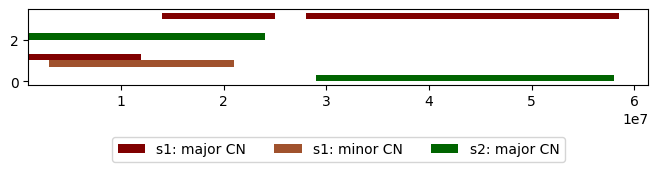

In [48]:
fig, ax = plt.subplots(1, 1, figsize=(8, 1), dpi=100)
colors = ["maroon", "sienna", "darkgreen", "olive"]
plot_bars(ax, cns_sid(cns_df, "s1"), "major_cn", colors[0], .3, .15, "s1: major CN")
plot_bars(ax, cns_sid(cns_df, "s1"), "minor_cn", colors[1], .3, -.15, "s1: minor CN")
plot_bars(ax, cns_sid(cns_df, "s2"), "major_cn", colors[2], .3, .15, "s2: major CN")
ax.legend(ncols=4, loc='upper center', bbox_to_anchor=(0.5, -0.6))

In [49]:
cns_fill_df = main_fill(cns_df, add_missing_chromosomes=False)
cns_fill_df

,sample_id,chrom,start,end,major_cn,minor_cn
0,s1,chr19,0,1000000,NaN,NaN
1,s1,chr19,1000000,3000000,1.0,NaN
2,s1,chr19,3000000,12000000,1.0,1.0
3,s1,chr19,12000000,14000000,NaN,1.0
4,s1,chr19,14000000,21000000,3.0,1.0
5,s1,chr19,21000000,25000000,3.0,NaN
6,s1,chr19,25000000,28000000,NaN,NaN
7,s1,chr19,28000000,58500000,3.0,NaN
8,s1,chr19,58500000,59128983,NaN,NaN
9,s2,chr19,0,1000000,NaN,NaN


In [50]:
cns_imp_df = main_impute(cns_fill_df)
cns_imp_df

,sample_id,chrom,start,end,major_cn,minor_cn
0,s1,chr19,0,13000000,1,1
1,s1,chr19,13000000,59128983,3,1
2,s2,chr19,0,26500000,2,0
3,s2,chr19,26500000,59128983,0,0


In [51]:
latex_cns_table(cns_imp_df, "cns_imp")

Saved C:\Users\adams\Ubuntu\cnsistent\docs\cns_imp.tex
CompletedProcess(args=['pdflatex', '-output-directory', 'C:\\Users\\adams\\Ubuntu\\cnsistent\\docs', 'C:\\Users\\adams\\Ubuntu\\cnsistent\\docs\\cns_imp.tex'], returncode=0)
Compiled C:\Users\adams\Ubuntu\cnsistent\docs\cns_imp.pdf


Text(26500000, 2, '  26.5MB  ')

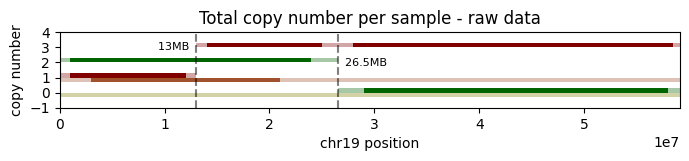

In [52]:
fig, ax = plt.subplots(1, 1, figsize=(8, 1), dpi=100)
plot_util(ax)
plot_bars(ax, cns_sid(cns_imp_df, "s1"), "major_cn", colors[0], .3, .15, "s1: major CN", alpha=.35)
plot_bars(ax, cns_sid(cns_imp_df, "s1"), "minor_cn", colors[1], .3, -.15, "s1: minor CN", alpha=.35)
plot_bars(ax, cns_sid(cns_imp_df, "s2"), "major_cn", colors[2], .3, .15, "s2: major CN", alpha=.35)
plot_bars(ax, cns_sid(cns_imp_df, "s2"), "minor_cn", colors[3], .3, -.15, "s2: minor CN", alpha=.35)
plot_bars(ax, cns_sid(cns_df, "s1"), "major_cn", colors[0], .3, .15, "s1: major CN")
plot_bars(ax, cns_sid(cns_df, "s1"), "minor_cn", colors[1], .3, -.15, "s1: minor CN")
plot_bars(ax, cns_sid(cns_df, "s2"), "major_cn", colors[2], .3, .15, "s2: major CN")
plot_bars(ax, cns_sid(cns_df, "s2"), "minor_cn", colors[3], .3, -.15, "s2: minor CN")
ax.axvline(13000000, color='k', linestyle='--', alpha=.5)
ax.text(13000000, 3, '  13MB  ', color='k', fontsize=8, ha='right', va='center')
ax.axvline(26500000, color='k', linestyle='--', alpha=.5)
ax.text(26500000, 2, '  26.5MB  ', color='k', fontsize=8, ha='left', va='center')

In [53]:
from cns.utils.gaps import hg19_gaps
from cns.utils.conversions import segs_to_df
from cns.process.segments import merge_segments
hg19_gaps_df = segs_to_df(merge_segments(tuples_to_segments(hg19_gaps)))
chr19_gaps_df = hg19_gaps_df[hg19_gaps_df["chrom"] == "chr19"].copy()
chr19_gaps_df["length"] = chr19_gaps_df["end"] - chr19_gaps_df["start"]
print(chr19_gaps_df)
latex_cns_table(chr19_gaps_df, "chr19_gaps", "|l|c|c|c|")

chr19_gaps_df_filter = chr19_gaps_df.query("length > 1000000").copy()
latex_cns_table(chr19_gaps_df_filter, "chr19_gaps_filter", "|l|c|c|c|")


     chrom     start       end   length
110  chr19         0     60000    60000
111  chr19   7346004   7396004    50000
112  chr19   8687198   8737198    50000
113  chr19  20523415  20573415    50000
114  chr19  24631782  27731782  3100000
115  chr19  59118983  59128983    10000
Saved C:\Users\adams\Ubuntu\cnsistent\docs\chr19_gaps.tex
CompletedProcess(args=['pdflatex', '-output-directory', 'C:\\Users\\adams\\Ubuntu\\cnsistent\\docs', 'C:\\Users\\adams\\Ubuntu\\cnsistent\\docs\\chr19_gaps.tex'], returncode=0)
Compiled C:\Users\adams\Ubuntu\cnsistent\docs\chr19_gaps.pdf
Saved C:\Users\adams\Ubuntu\cnsistent\docs\chr19_gaps_filter.tex
CompletedProcess(args=['pdflatex', '-output-directory', 'C:\\Users\\adams\\Ubuntu\\cnsistent\\docs', 'C:\\Users\\adams\\Ubuntu\\cnsistent\\docs\\chr19_gaps_filter.tex'], returncode=0)
Compiled C:\Users\adams\Ubuntu\cnsistent\docs\chr19_gaps_filter.pdf


In [54]:
chr19_gaps_df_filter.iloc[0]["start"]

24631782

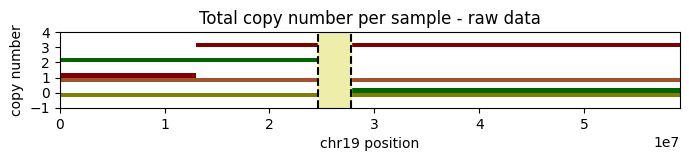

In [55]:
cent_seg = chr19_gaps_df_filter.iloc[0]

fig, ax = plt.subplots(1, 1, figsize=(8, 1), dpi=100)
plot_util(ax)
plot_bars(ax, cns_sid(cns_imp_df, "s1"), "major_cn", colors[0], .3, .15, "s1: major CN")
plot_bars(ax, cns_sid(cns_imp_df, "s1"), "minor_cn", colors[1], .3, -.15, "s1: minor CN")
plot_bars(ax, cns_sid(cns_imp_df, "s2"), "major_cn", colors[2], .3, .15, "s2: major CN")
plot_bars(ax, cns_sid(cns_imp_df, "s2"), "minor_cn", colors[3], .3, -.15, "s2: minor CN")


ax.fill_between([cent_seg["start"], cent_seg["end"]], -1, 5, color='#EEEEAA', alpha=1)
ax.axvline(x=cent_seg["start"], color='k', linestyle='--')
ax.axvline(x=cent_seg["end"], color='k', linestyle='--')

In [56]:
remove_segs = filter_min_size(regions_remove("gaps"), 100000)
remove_segs["chr19"]

[(24631782, 27731782)]

In [57]:
cns_imp_df

,sample_id,chrom,start,end,major_cn,minor_cn
0,s1,chr19,0,13000000,1,1
1,s1,chr19,13000000,59128983,3,1
2,s2,chr19,0,26500000,2,0
3,s2,chr19,26500000,59128983,0,0


In [58]:
segs = main_segment(cns_imp_df, select_segs={"chr19": genome_to_segments()["chr19"]}, remove_segs=remove_segs, split_size=5000000)
print(segs)

{'chr19': [(0, 4926356), (4926356, 9852713), (9852713, 14779069), (14779069, 19705426), (19705426, 24631782), (27731782, 32964649), (32964649, 38197516), (38197516, 43430383), (43430383, 48663249), (48663249, 53896116), (53896116, 59128983)]}


In [59]:
breaks = get_breaks_from_segments(segs)["chr19"]
print("breaks", breaks)
print("Left size", breaks[1] - breaks[0])
print("Right size", breaks[-1] - breaks[-2])


breaks [0, 4926356, 9852713, 14779069, 19705426, 24631782, 27731782, 32964649, 38197516, 43430383, 48663249, 53896116, 59128983]
Left size 4926356
Right size 5232867


In [60]:
bin_res_df = main_bin(cns_imp_df, segs)
bin_res_df

,sample_id,chrom,start,end,major_cn,minor_cn
0,s1,chr19,0,4926356,1.000000,1.0
1,s1,chr19,4926356,9852713,1.000000,1.0
2,s1,chr19,9852713,14779069,1.722266,1.0
3,s1,chr19,14779069,19705426,3.000000,1.0
4,s1,chr19,19705426,24631782,3.000000,1.0
5,s1,chr19,27731782,32964649,3.000000,1.0
6,s1,chr19,32964649,38197516,3.000000,1.0
7,s1,chr19,38197516,43430383,3.000000,1.0
8,s1,chr19,43430383,48663249,3.000000,1.0
9,s1,chr19,48663249,53896116,3.000000,1.0


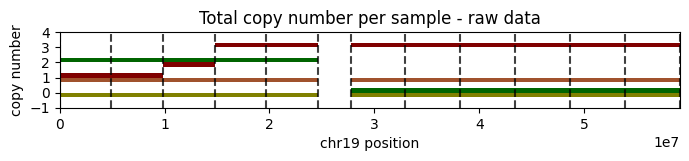

In [61]:
cent_seg = chr19_gaps_df_filter.iloc[0]

fig, ax = plt.subplots(1, 1, figsize=(8, 1), dpi=100)
plot_util(ax)
plot_bars(ax, cns_sid(bin_res_df, "s1"), "major_cn", colors[0], .3, .15, "s1: major CN")
plot_bars(ax, cns_sid(bin_res_df, "s1"), "minor_cn", colors[1], .3, -.15, "s1: minor CN")
plot_bars(ax, cns_sid(bin_res_df, "s2"), "major_cn", colors[2], .3, .15, "s2: major CN")
plot_bars(ax, cns_sid(bin_res_df, "s2"), "minor_cn", colors[3], .3, -.15, "s2: minor CN")

for brekapoint in breaks:
    ax.axvline(x=brekapoint, color='k', linestyle='--', alpha=.75)

In [113]:

pd.options.display.float_format = '{:.2f}'.format
ext_df = add_cns_loc(bin_res_df)
feat_table = ext_df.query("sample_id == 's1'")[["mid", "major_cn", "minor_cn"]].rename(columns={"mid": "feature"}).set_index("feature").T
feat_table.index.name = "track"
feat_table["sample"] = "s1"
feat_table = feat_table.reset_index().set_index(["sample", "track"])
feat_table

feature          2463178   7389534   12315891  ...  46046816  51279682  56512549
sample track                                   ...                              
s1     major_cn      1.00      1.00      1.72  ...      3.00      3.00      3.00
       minor_cn      1.00      1.00      1.00  ...      1.00      1.00      1.00

[2 rows x 11 columns]